In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interactive
from scipy.stats import norm

%matplotlib inline

# Disposición a pagar [willingness to pay]

La demanda de un producto está determinada por la integración de decisiones tomadas por cada individuo que compone al mercado: comprar o no comprar en función del precio del producto.

De manera simplificada, suponemos que cada individuo establece un precio máximo a pagar para adquirir un artículo, al cual llamamos **disposición a pagar**. Si el precio del producto es menor a dicho precio, el individuo adquiere el producto, y no lo adquiere en caso de que el precio sea mayor.  

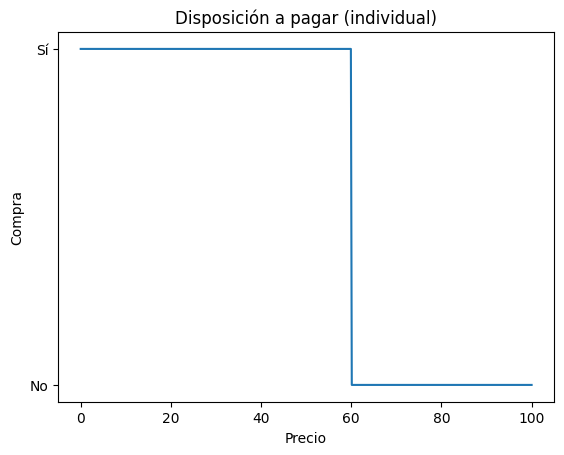

In [ ]:
p = np.linspace(0, 100, 500)
dp = 60

fig,ax = plt.subplots(1)

y = np.where(p > dp, 0, 1)

plt.plot(p, y)
ax.set_yticks((0, 1))
ax.set_yticklabels(("No", "Sí"))
plt.xlabel("Precio")
plt.ylabel("Compra")
plt.title("Disposición a pagar (individual)")
plt.show()


Supongamos que averiguamos la disposición a pagar de cada individuo. Podemos utilizar un **histograma de frecuencias** para explorar su distribución.

Revisemos algunos ejemplos que se podrían obtener con dicho ejercicio.

## Distribución uniforme


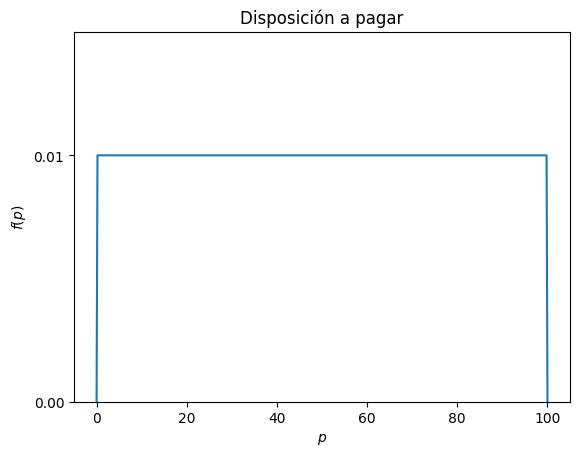

In [ ]:
p = np.linspace(0, 100, 500)

y = 1/100*np.ones(500)
y[0] = 0
y[-1] = 0

fig,ax = plt.subplots(1)

plt.plot(p, y)
plt.xlabel("$p$")
plt.ylabel("$f(p)$")
plt.ylim(0,0.015)

ax.set_yticks((0, 0.01))
#ax.set_yticklabels(("No", "Sí"))

plt.title("Disposición a pagar")
plt.show()


## Distribución normal

Una distribución uniforme puede ser cuestionable. En general podemos esperar que la disposición a pagar se concentre alrededor del valor que el mercado establece al producto:

In [ ]:
p = np.linspace(0, 100, 500)

def f(v, s):
    norm(loc=v,scale=s)
    y = norm.pdf(p,v,s)
    fig,ax = plt.subplots(1)

    plt.plot(p, y)
    plt.xlabel("$p$")
    plt.ylabel("$d(p)$")
    plt.ylim(0, 0.09)

    plt.show()

interactive_plot = interactive(f, v=(50, 100), s=(5,20))
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot


interactive(children=(IntSlider(value=75, description='v', min=50), IntSlider(value=12, description='s', max=2…

### Ejemplo 1

Si la disposición a pagar por un producto se distribuye normalmente con media de $\$75$ y desviación estándar de $\$12$, ¿qué proporción del mercado tiene una disposición a pagar mayor a $\$85$?.

**Solución**

Para responder la pregunta, evaluamos el complemento de la función de probabilidad acumulada de la disposición a pagar:

$$1-\Phi(85; 75, 12) = 0.2$$

In [ ]:
from scipy.stats import norm

In [ ]:
1-norm.cdf(85,loc=75,scale=12)


np.float64(0.20232838096364314)

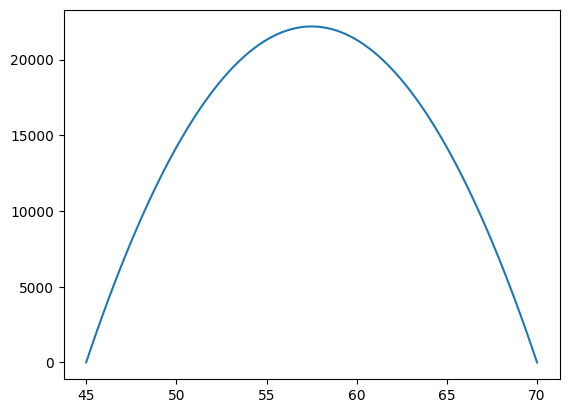

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

p = np.linspace(45, 70, 100)
G = 142*(70-p)*(p-45)

plt.plot(p, G)
plt.show()

# Demanda [respuesta al precio]

La demanda de un producto queda establecida a partir de la distribución de la disposición a pagar:

$$\color{blue}{d(p) = D\int_{p}^{\infty}f(p)dp}$$

siendo $D$ la máxima demanda que el producto puede presentar (el mercado potencial).

A esta función también se le conoce como **respuesta al precio**.

La expresión $\int_{p}^{\infty}f(p)dp$ es igual a la **probabilidad de que algún consumidor tenga una disposición a pagar mayor al precio** $p$ y no es más que el área bajo la gráfica de la densidad de la disposición a pagar a partir del precio $p$.

### Ejemplo 2

Suponemos que la disposición a pagar por un producto sigue una distribución uniforme:

$$f(p) = \frac{1}{30},$$

para  $p \in [0, 30]$

Como se muestra en la siguiente gráfica:

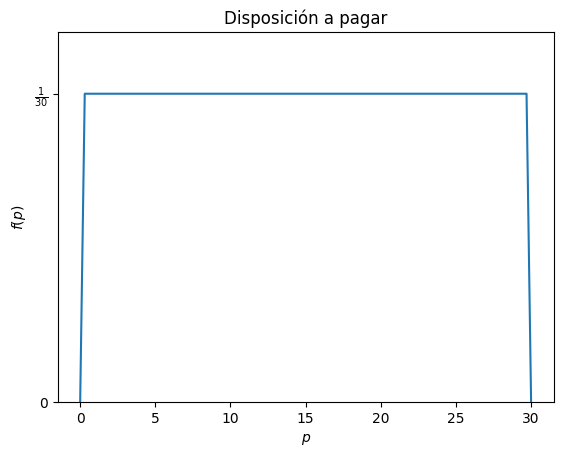

In [ ]:
p = np.linspace(0, 30, 100)

y = 1/30*np.ones(100)
y[0] = 0
y[-1] = 0

fig,ax = plt.subplots(1)

plt.plot(p, y)
plt.xlabel("$p$")
plt.ylabel("$f(p)$")
plt.ylim(0,0.040)

ax.set_yticks((0, 1/30))
ax.set_yticklabels((0, "$\\frac{1}{30}$"))

plt.title("Disposición a pagar")
plt.show()


Si $D = 5000$, entonces la función de demanda es la siguiente:

$$d(p) = D\int_{p}^{\infty}f(p)dp = 5000\times(30-p)\frac{1}{30}$$

In [ ]:
from matplotlib.patches import Rectangle
px = np.linspace(0, 30, 100)

y = 1/30*np.ones(100)
y[0] = 0
y[-1] = 0

def f(p):

    fig,ax = plt.subplots(1)

    plt.plot(px, y)
    plt.xlabel("$p$")
    plt.ylabel("$f(p)$")
    plt.ylim(0,0.040)

    ax.set_yticks((0, 1/30))
    ax.set_yticklabels((0, "$\\frac{1}{30}$"))

    ax.add_patch( Rectangle((p, 0), 30-p, 1/30) )

    plt.text(8, 1/30+0.01, "$\int_{"+str(p)+"}^{30} f(p)dp = \\frac{1}{30}\\times [30-"+ str(p)+"] = " + str(np.round((30-p)/30,3))+"$")
    plt.show()


interactive_plot = interactive(f, p=(0, 30))
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

<>:22: SyntaxWarning: invalid escape sequence '\i'
<>:22: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_472/4051936643.py:22: SyntaxWarning: invalid escape sequence '\i'
  plt.text(8, 1/30+0.01, "$\int_{"+str(p)+"}^{30} f(p)dp = \\frac{1}{30}\\times [30-"+ str(p)+"] = " + str(np.round((30-p)/30,3))+"$")


interactive(children=(IntSlider(value=15, description='p', max=30), Output(layout=Layout(height='350px'))), _d…

La función de demanda es:

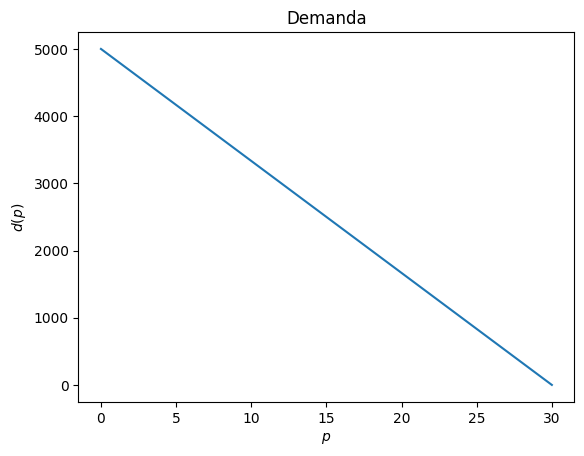

In [ ]:
p = np.linspace(0, 30, 100)

d = 5000*(30-p)/30

fig,ax = plt.subplots(1)

plt.plot(p, d)
plt.xlabel("$p$")
plt.ylabel("$d(p)$")
plt.title("Demanda")
plt.show()


**Observa que la demanda es una función lineal para una disposición a pagar uniformemente distribuida.**

### Ejemplo 3

La función de demanda para un producto que presenta una disposición a pagar normal con media en $80$ pesos, desviación estándar de $10$ pesos y demanda máxima de 10,000 unidades es:

$$ d(p) = 10,000\left[1-\Phi(p; 80, 10)\right]$$

siendo $\Phi(p; 80, 10)$ la densidad acumulada de una normal con media de 80 y desviación estpandar de 10.

La gráfica de la función se puede visualizar en la siguiente celda:


In [ ]:
from scipy.stats import norm


10000*(1-norm.cdf(100,80,10))

np.float64(227.50131948179208)

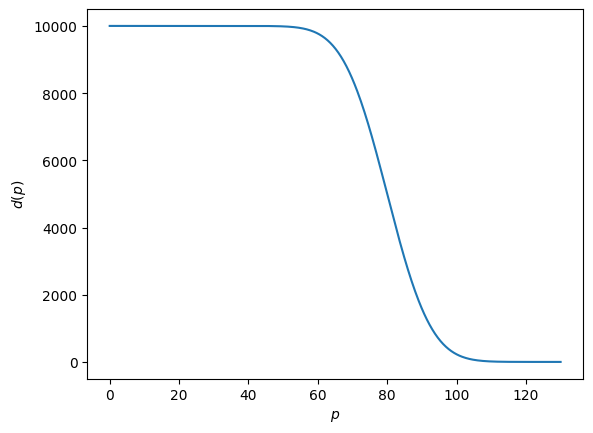

In [ ]:
from scipy.stats import norm

p = np.linspace(0, 130, 500)

v = 80
s = 10

norm(loc=v,scale=s)

y = 10000*(1-norm.cdf(p,v,s))

fig,ax = plt.subplots(1)

plt.plot(p, y)
plt.xlabel("$p$")
plt.ylabel("$d(p)$")

#ax.set_yticks((0.04, 0.08))

#plt.title("Disposición a pagar")
plt.show()


En la siguiente celda puedes explorar la función de demanda que se obtiene, bajo una disposición a pagar normal, para diferentes parámetros:

In [ ]:
p = np.linspace(0, 130, 500)

def f(v, s):
    norm(loc=v,scale=s)
    y = 10000*(1-norm.cdf(p,v,s))

    fig,ax = plt.subplots(1)

    plt.plot(p, y)
    plt.xlabel("$p$")
    plt.ylabel("$d(p)$")

    plt.show()

interactive_plot = interactive(f, v=(50, 100), s=(5,20))
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot


<font color="red">Ejercicios</font>

1. El mercado potencial para una libreta de espiral es $D = 20,000$ y la disposición a pagar se distribuye uniformemente entre $\$0$ y $\$100$ pesos, ¿cuál es la función de respuesta al precio?


Si $D = 20000$, entonces la función de demanda es la siguiente:

$$d(p) = D\int_{p}^{100}f(p)dp = 20000\times(100-p)\frac{1}{100}$$

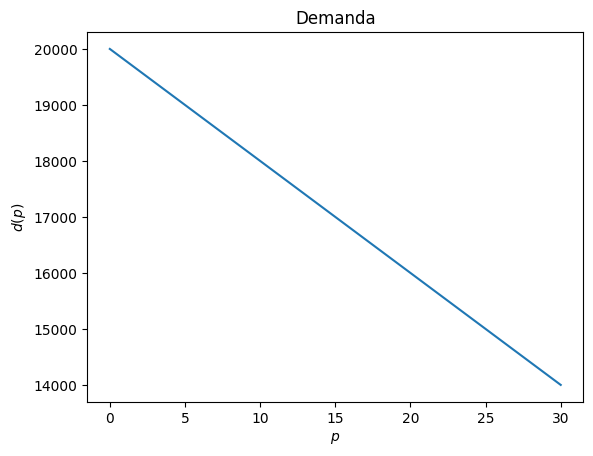

In [11]:
p = np.linspace(0, 30, 100)

d = 20000*(100-p)/100

fig,ax = plt.subplots(1)

plt.plot(p, d)
plt.xlabel("$p$")
plt.ylabel("$d(p)$")
plt.title("Demanda")
plt.show()

2. Si la disposición a pagar en el ejemplo anterior se distribuye normalmente, con media de 50 pesos y desviación estándar de 20 pesos, ¿cuál es la demanda esperada para un precio de 65 pesos?.

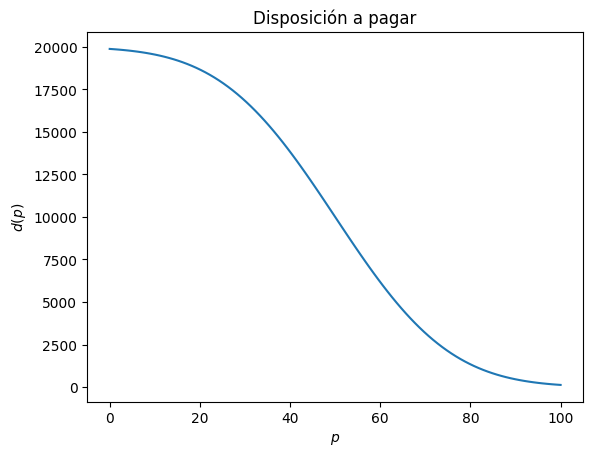

La demanda esperada para un precio de $65 es: 4532.55


In [12]:
from scipy.stats import norm

p = np.linspace(0, 100, 100)

v = 50
s = 20

norm(loc=v,scale=s)

y = 20000*(1-norm.cdf(p,v,s))

fig,ax = plt.subplots(1)

plt.plot(p, y)
plt.xlabel("$p$")
plt.ylabel("$d(p)$")

#ax.set_yticks((0.04, 0.08))

plt.title("Disposición a pagar")
plt.show()

demand_at_65 = 20000*(1 - norm.cdf(65, loc=v, scale=s))
print(f"La demanda esperada para un precio de $65 es: {demand_at_65:.2f}")